In [40]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset
# Load the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleaning
df["job_posted_date"]=pd.to_datetime(df["job_posted_date"])
df["job_skills"]=df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

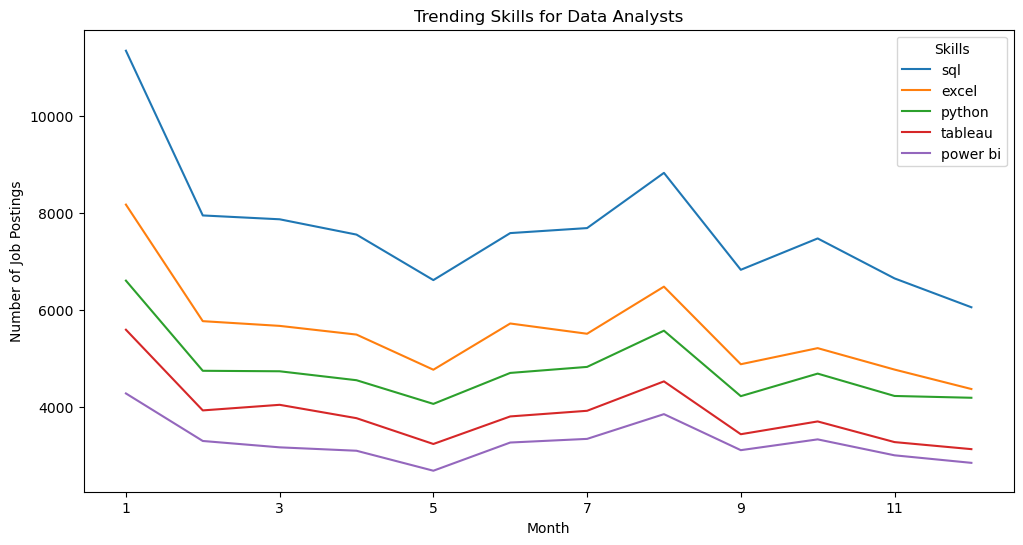

In [41]:
df_DA=df[df["job_title_short"]=="Data Analyst"].copy()
df_DA["job_posted_month_no"]=df_DA['job_posted_date'].dt.month
df_DA_exploded=df_DA.explode("job_skills")
df_DA_pivot=df_DA_exploded.pivot_table(index="job_posted_month_no", columns="job_skills", aggfunc="size", fill_value=0)
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
sortiing=df_DA_pivot.loc['Total'].sort_values(ascending=False).index
df_DA_pivot=df_DA_pivot[sortiing]
df_DA_pivot=df_DA_pivot.drop("Total")
df_DA_pivot.iloc[:,:5].plot(kind='line', figsize=(12,6))
plt.title("Trending Skills for Data Analysts")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.legend(title="Skills")
plt.show()

In [42]:
df_DA_pivot.iloc[:,:5]

job_skills,sql,excel,python,tableau,power bi
job_posted_month_no,,,,,
1,11336,8170,6606,5596,4285
2,7947,5772,4751,3936,3307
3,7868,5675,4741,4051,3176
4,7553,5496,4557,3776,3106
5,6617,4773,4070,3245,2695
6,7584,5724,4707,3812,3275
7,7687,5513,4831,3928,3350
8,8823,6482,5576,4533,3859
9,6829,4886,4229,3446,3118


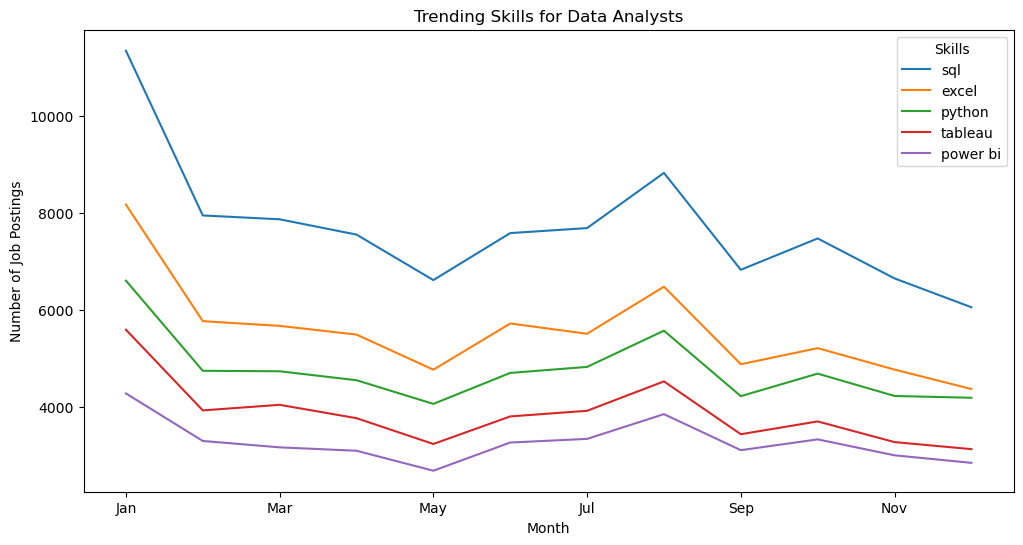

In [44]:
df_DA_pivot.index= df_DA_pivot.index.map(lambda x: calendar.month_abbr[int(x)])

df_DA_pivot.iloc[:,:5].plot(kind='line', figsize=(12,6))
plt.title("Trending Skills for Data Analysts")
plt.xlabel("Month")
plt.ylabel("Number of Job Postings")
plt.legend(title="Skills")